# 1. Title and objective

**Notebook:** Crypto Data Engineering and Visualization for Motif Discovery

This notebook prepares the next thesis stage after raw and processed data collection. It loads the processed BTCUSDT and ETHUSDT 1-minute datasets, inspects schema consistency, quantifies missingness and continuity, visualizes key signals, and defines a defensible motif-ready representation for later matrix profile experiments.

The objective is to make the preprocessing decisions explicit and academically defensible before any motif mining is attempted.

# 2. Imports and project paths

The notebook uses project-relative paths via `pathlib` and imports a small helper module from `src/analysis` to keep notebook code concise and reproducible.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

current = Path.cwd().resolve()
while current != current.parent and not (current / "src").exists():
    current = current.parent
if not (current / "src").exists():
    raise FileNotFoundError("Could not locate project root containing src/.")

project_root = current
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.analysis.crypto_notebook_utils import (
    EXPECTED_FREQUENCY,
    build_contiguous_block_table,
    build_dtype_table,
    build_gap_run_table,
    build_missingness_table,
    build_summary_table,
    load_asset_bundle,
    make_recent_window,
    make_reindexed_diagnostic_frame,
)

ASSETS = ["BTCUSDT", "ETHUSDT"]
FEATURE_COLUMNS = [
    "log_return",
    "pct_return",
    "volatility_30m",
    "volatility_60m",
    "volatility_240m",
    "realized_volatility_60m",
]
RECENT_WINDOW_DAYS = 30

print(f"Project root: {project_root}")

Project root: C:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis


# 3. Load BTC and ETH processed datasets

The notebook reads the existing processed parquet files and their metadata diagnostics. It does not overwrite any raw or processed source file.

In [2]:
asset_bundles = {symbol: load_asset_bundle(project_root, symbol) for symbol in ASSETS}

load_overview = pd.DataFrame(
    [
        {
            "symbol": symbol,
            "processed_path": str(bundle["processed_path"].relative_to(project_root)),
            "rows": len(bundle["df"]),
            "start_utc": bundle["df"]["timestamp"].min(),
            "end_utc": bundle["df"]["timestamp"].max(),
        }
        for symbol, bundle in asset_bundles.items()
    ]
)
display(load_overview)

for symbol in ASSETS:
    print(f"Preview for {symbol}")
    display(asset_bundles[symbol]["df"].head(3))

,symbol,processed_path,rows,start_utc,end_utc
0,BTCUSDT,data\processed\crypto\1min\BTCUSDT_1m_processe...,4502648,2017-08-17 04:00:00+00:00,2026-03-15 23:59:00+00:00
1,ETHUSDT,data\processed\crypto\1min\ETHUSDT_1m_processe...,4504088,2017-08-17 04:00:00+00:00,2026-03-16 23:59:00+00:00


Preview for BTCUSDT


,timestamp,open,high,low,close,volume,log_return,pct_return,volatility_30m,volatility_60m,volatility_240m,realized_volatility_60m
0,2017-08-17 04:00:00+00:00,4261.48,4261.48,4261.48,4261.48,1.775183,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-08-17 04:01:00+00:00,4261.48,4261.48,4261.48,4261.48,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
2,2017-08-17 04:02:00+00:00,4280.56,4280.56,4280.56,4280.56,0.261074,0.004467,0.004477,NaN,NaN,NaN,NaN


Preview for ETHUSDT


,timestamp,open,high,low,close,volume,log_return,pct_return,volatility_30m,volatility_60m,volatility_240m,realized_volatility_60m
0,2017-08-17 04:00:00+00:00,301.13,301.13,301.13,301.13,0.42643,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-08-17 04:01:00+00:00,301.13,301.13,301.13,301.13,2.75787,0.00000,0.000000,NaN,NaN,NaN,NaN
2,2017-08-17 04:02:00+00:00,300.00,300.00,300.00,300.00,0.09930,-0.00376,-0.003753,NaN,NaN,NaN,NaN


# 4. Schema and dtype consistency checks

Before any cross-asset analysis, the two datasets should have matching columns and compatible dtypes. This is a prerequisite for later benchmarking and motif experiments.

In [3]:
btc_columns = set(asset_bundles["BTCUSDT"]["df"].columns)
eth_columns = set(asset_bundles["ETHUSDT"]["df"].columns)
print("Column sets identical:", btc_columns == eth_columns)

dtype_table = build_dtype_table(asset_bundles)
display(dtype_table)

column_order_check = pd.DataFrame(
    {
        symbol: list(asset_bundles[symbol]["df"].columns)
        for symbol in ASSETS
    }
)
display(column_order_check)

Column sets identical: True


symbol,BTCUSDT,ETHUSDT
column,,
close,float64,float64
high,float64,float64
log_return,float64,float64
low,float64,float64
open,float64,float64
pct_return,float64,float64
realized_volatility_60m,float64,float64
timestamp,"datetime64[ms, UTC]","datetime64[ms, UTC]"
volatility_240m,float64,float64


,BTCUSDT,ETHUSDT
0,timestamp,timestamp
1,open,open
2,high,high
3,low,low
4,close,close
5,volume,volume
6,log_return,log_return
7,pct_return,pct_return
8,volatility_30m,volatility_30m
9,volatility_60m,volatility_60m


# 5. Missing values and rolling-window NaN analysis

Not all missing values are problematic. For return and rolling volatility features, leading NaNs are mathematically unavoidable because the features require lagged or rolling observations. Internal NaNs would be more concerning because they could indicate a broken preprocessing step.

In [4]:
missingness_table = build_missingness_table(
    asset_bundles,
    ["open", "high", "low", "close", "volume", *FEATURE_COLUMNS],
)

display(missingness_table.pivot(index="column", columns="symbol", values="total_nan"))
display(missingness_table.pivot(index="column", columns="symbol", values="leading_nan"))
display(missingness_table.loc[missingness_table["internal_nan"] > 0].sort_values(["symbol", "column"]))

symbol,BTCUSDT,ETHUSDT
column,,
close,0,0
high,0,0
log_return,1,1
low,0,0
open,0,0
pct_return,1,1
realized_volatility_60m,60,60
volatility_240m,240,240
volatility_30m,30,30


symbol,BTCUSDT,ETHUSDT
column,,
close,0,0
high,0,0
log_return,1,1
low,0,0
open,0,0
pct_return,1,1
realized_volatility_60m,60,60
volatility_240m,240,240
volatility_30m,30,30


,symbol,column,total_nan,leading_nan,internal_nan


Interpretation:

- `log_return` should have one leading NaN because the first return cannot be computed.
- Rolling volatility features should have warm-up NaNs at the start equal to their effective window initialization.
- If internal NaNs appear away from the beginning, they should be investigated before motif mining.

# 6. Coverage and continuity analysis

The processed parquet files contain only observed bars. Therefore, continuity has to be evaluated by comparing the observed timestamp coverage against the ideal complete 1-minute grid implied by the first and last timestamp.

In [5]:
summary_table = build_summary_table(asset_bundles)
display(summary_table)

continuity_rows = []
for symbol, bundle in asset_bundles.items():
    df = bundle["df"]
    observed_deltas = df["timestamp"].diff().dropna()
    continuity_rows.append(
        {
            "symbol": symbol,
            "most_common_gap_seconds": observed_deltas.dt.total_seconds().mode().iloc[0],
            "max_gap_seconds": observed_deltas.dt.total_seconds().max(),
            "irregular_gap_count": int((observed_deltas != EXPECTED_FREQUENCY).sum()),
        }
    )

continuity_table = pd.DataFrame(continuity_rows).sort_values("symbol").reset_index(drop=True)
display(continuity_table)

,symbol,rows,start_utc,end_utc,expected_rows_if_continuous,coverage_ratio,duplicate_timestamps,missing_intervals,irregular_intervals
0,BTCUSDT,4502648,2017-08-17 04:00:00+00:00,2026-03-15 23:59:00+00:00,4511280,0.998087,0,8632,35
1,ETHUSDT,4504088,2017-08-17 04:00:00+00:00,2026-03-16 23:59:00+00:00,4512720,0.998087,0,8632,35


,symbol,most_common_gap_seconds,max_gap_seconds,irregular_gap_count
0,BTCUSDT,60.0,120720.0,35
1,ETHUSDT,60.0,120720.0,35


# 7. Missing timestamp diagnostics using metadata CSVs

The metadata CSV files expose the exact missing minute timestamps detected during validation. Grouping them into contiguous runs makes the continuity problem easier to interpret and explain.

In [6]:
gap_run_summaries = {symbol: build_gap_run_table(bundle["missing_df"]) for symbol, bundle in asset_bundles.items()}

gap_overview = pd.DataFrame(
    [
        {
            "symbol": symbol,
            "gap_runs": len(gap_run_summaries[symbol]),
            "missing_minutes": int(bundle["report"]["missing_intervals_count"]),
            "largest_gap_minutes": int(gap_run_summaries[symbol]["missing_minutes"].max()) if not gap_run_summaries[symbol].empty else 0,
            "median_gap_minutes": float(gap_run_summaries[symbol]["missing_minutes"].median()) if not gap_run_summaries[symbol].empty else 0.0,
        }
        for symbol, bundle in asset_bundles.items()
    ]
)
display(gap_overview)

for symbol in ASSETS:
    print(f"Top 10 gap runs for {symbol}")
    display(gap_run_summaries[symbol].head(10))

,symbol,gap_runs,missing_minutes,largest_gap_minutes,median_gap_minutes
0,BTCUSDT,35,8632,2011,128.0
1,ETHUSDT,35,8632,2011,128.0


Top 10 gap runs for BTCUSDT


,gap_start,gap_end,missing_minutes
0,2017-09-06 16:01:00+00:00,2017-09-06 22:59:00+00:00,419
1,2017-12-04 06:01:00+00:00,2017-12-04 06:48:00+00:00,48
2,2017-12-18 10:01:00+00:00,2017-12-18 10:13:00+00:00,13
3,2017-12-18 12:30:00+00:00,2017-12-18 13:33:00+00:00,64
4,2018-01-04 03:01:00+00:00,2018-01-04 05:05:00+00:00,125
5,2018-02-08 00:29:00+00:00,2018-02-09 09:59:00+00:00,2011
6,2018-02-10 06:00:00+00:00,2018-02-10 06:14:00+00:00,15
7,2018-02-11 04:01:00+00:00,2018-02-11 04:34:00+00:00,34
8,2018-06-26 02:00:00+00:00,2018-06-26 11:59:00+00:00,600
9,2018-06-27 13:00:00+00:00,2018-06-27 14:44:00+00:00,105


Top 10 gap runs for ETHUSDT


,gap_start,gap_end,missing_minutes
0,2017-09-06 16:01:00+00:00,2017-09-06 22:59:00+00:00,419
1,2017-12-04 06:01:00+00:00,2017-12-04 06:48:00+00:00,48
2,2017-12-18 10:01:00+00:00,2017-12-18 10:13:00+00:00,13
3,2017-12-18 12:30:00+00:00,2017-12-18 13:33:00+00:00,64
4,2018-01-04 03:01:00+00:00,2018-01-04 05:05:00+00:00,125
5,2018-02-08 00:29:00+00:00,2018-02-09 09:59:00+00:00,2011
6,2018-02-10 06:00:00+00:00,2018-02-10 06:14:00+00:00,15
7,2018-02-11 04:01:00+00:00,2018-02-11 04:34:00+00:00,34
8,2018-06-26 02:00:00+00:00,2018-06-26 11:59:00+00:00,600
9,2018-06-27 13:00:00+00:00,2018-06-27 14:44:00+00:00,105


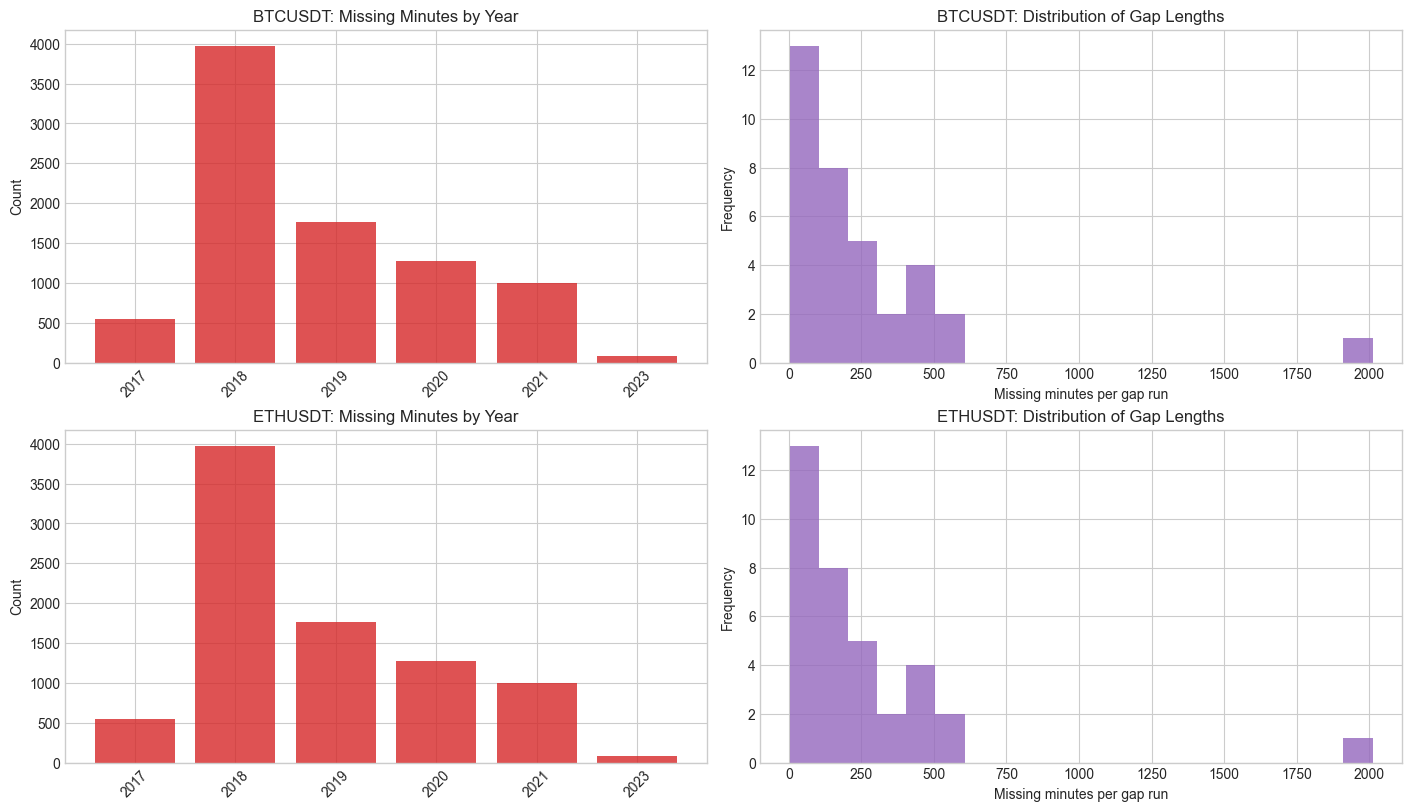

In [7]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8), constrained_layout=True)

for row_idx, symbol in enumerate(ASSETS):
    missing_df = asset_bundles[symbol]["missing_df"]
    gap_runs = gap_run_summaries[symbol]

    if not missing_df.empty:
        by_year = missing_df.assign(year=missing_df["timestamp"].dt.year).groupby("year").size()
        axes[row_idx, 0].bar(by_year.index.astype(str), by_year.values, color="tab:red", alpha=0.8)
    axes[row_idx, 0].set_title(f"{symbol}: Missing Minutes by Year")
    axes[row_idx, 0].set_ylabel("Count")
    axes[row_idx, 0].tick_params(axis="x", rotation=45)

    if not gap_runs.empty:
        axes[row_idx, 1].hist(gap_runs["missing_minutes"], bins=min(20, len(gap_runs)), color="tab:purple", alpha=0.8)
    axes[row_idx, 1].set_title(f"{symbol}: Distribution of Gap Lengths")
    axes[row_idx, 1].set_xlabel("Missing minutes per gap run")
    axes[row_idx, 1].set_ylabel("Frequency")

plt.show()

# 8. Summary comparison table for BTC vs ETH

The table below is intended as a compact thesis-meeting view of the current state of the two assets.

In [8]:
comparison_table = summary_table.merge(
    gap_overview[["symbol", "gap_runs", "largest_gap_minutes", "median_gap_minutes"]],
    on="symbol",
    how="left",
)
display(comparison_table)

,symbol,rows,start_utc,end_utc,expected_rows_if_continuous,coverage_ratio,duplicate_timestamps,missing_intervals,irregular_intervals,gap_runs,largest_gap_minutes,median_gap_minutes
0,BTCUSDT,4502648,2017-08-17 04:00:00+00:00,2026-03-15 23:59:00+00:00,4511280,0.998087,0,8632,35,35,2011,128.0
1,ETHUSDT,4504088,2017-08-17 04:00:00+00:00,2026-03-16 23:59:00+00:00,4512720,0.998087,0,8632,35,35,2011,128.0


# 9. Visualizations:

This section provides the required plots for close, `log_return`, `pct_return`, the four volatility features, return distributions, and BTC-vs-ETH comparisons. Full-history price views are resampled for readability; recent windows preserve minute-level behavior.

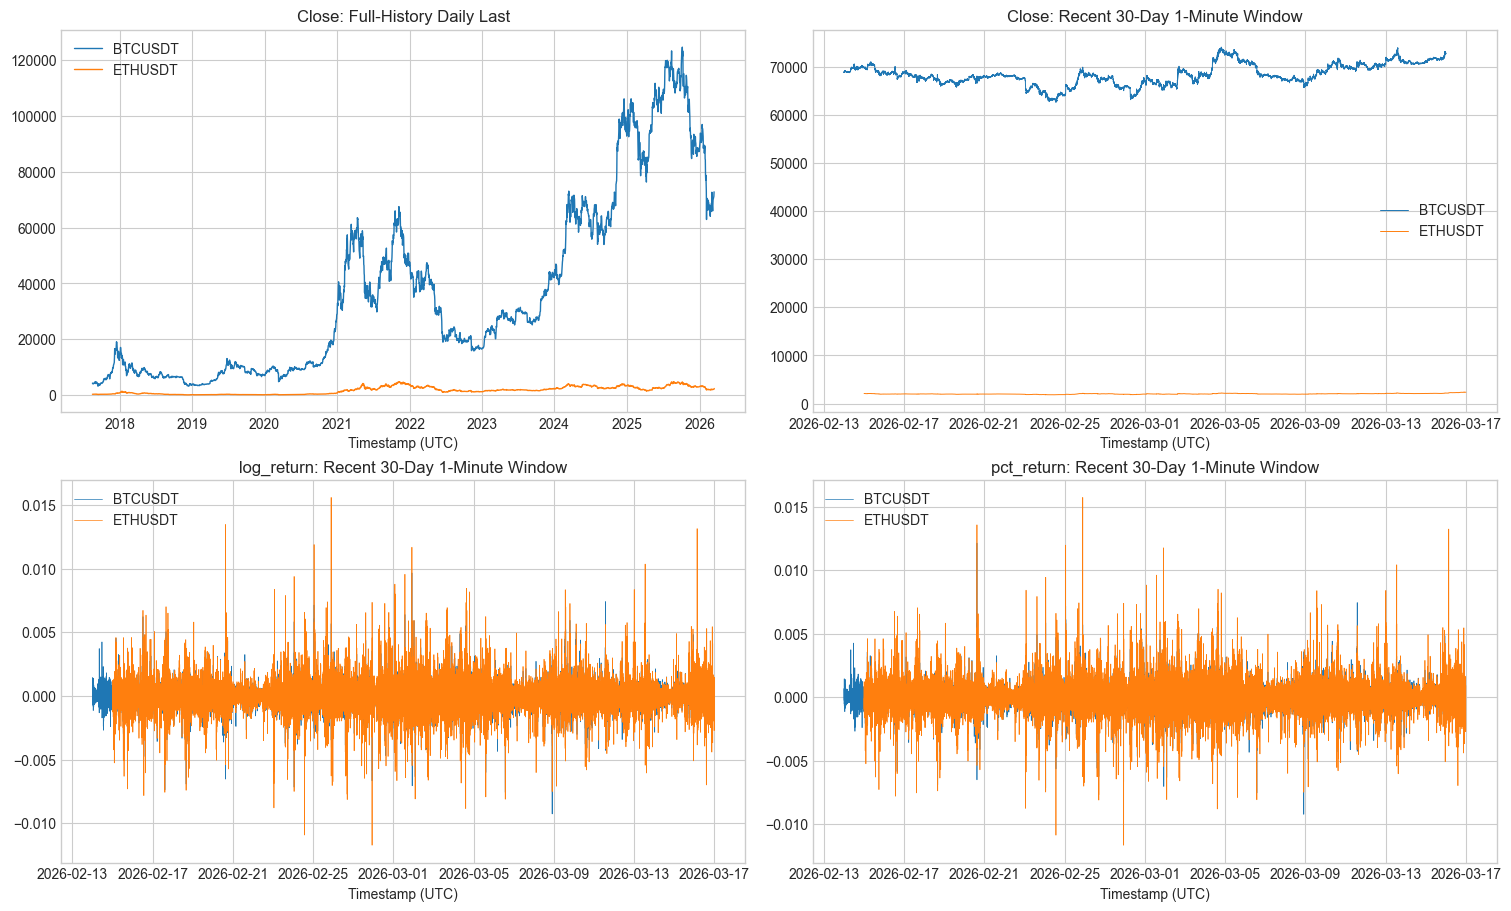

In [9]:
daily_close = {}
recent_frames = {}

for symbol, bundle in asset_bundles.items():
    df = bundle["df"]
    daily_close[symbol] = df.set_index("timestamp")["close"].resample("1D").last().dropna()
    recent_frames[symbol] = make_recent_window(df, RECENT_WINDOW_DAYS)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 9), constrained_layout=True)
for symbol in ASSETS:
    recent_df = recent_frames[symbol]
    axes[0, 0].plot(daily_close[symbol].index, daily_close[symbol].values, label=symbol, linewidth=1.0)
    axes[0, 1].plot(recent_df["timestamp"], recent_df["close"], label=symbol, linewidth=0.7)
    axes[1, 0].plot(recent_df["timestamp"], recent_df["log_return"], label=symbol, linewidth=0.5)
    axes[1, 1].plot(recent_df["timestamp"], recent_df["pct_return"], label=symbol, linewidth=0.5)

axes[0, 0].set_title("Close: Full-History Daily Last")
axes[0, 1].set_title(f"Close: Recent {RECENT_WINDOW_DAYS}-Day 1-Minute Window")
axes[1, 0].set_title(f"log_return: Recent {RECENT_WINDOW_DAYS}-Day 1-Minute Window")
axes[1, 1].set_title(f"pct_return: Recent {RECENT_WINDOW_DAYS}-Day 1-Minute Window")

for ax in axes.flat:
    ax.set_xlabel("Timestamp (UTC)")
    ax.legend()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())

plt.show()

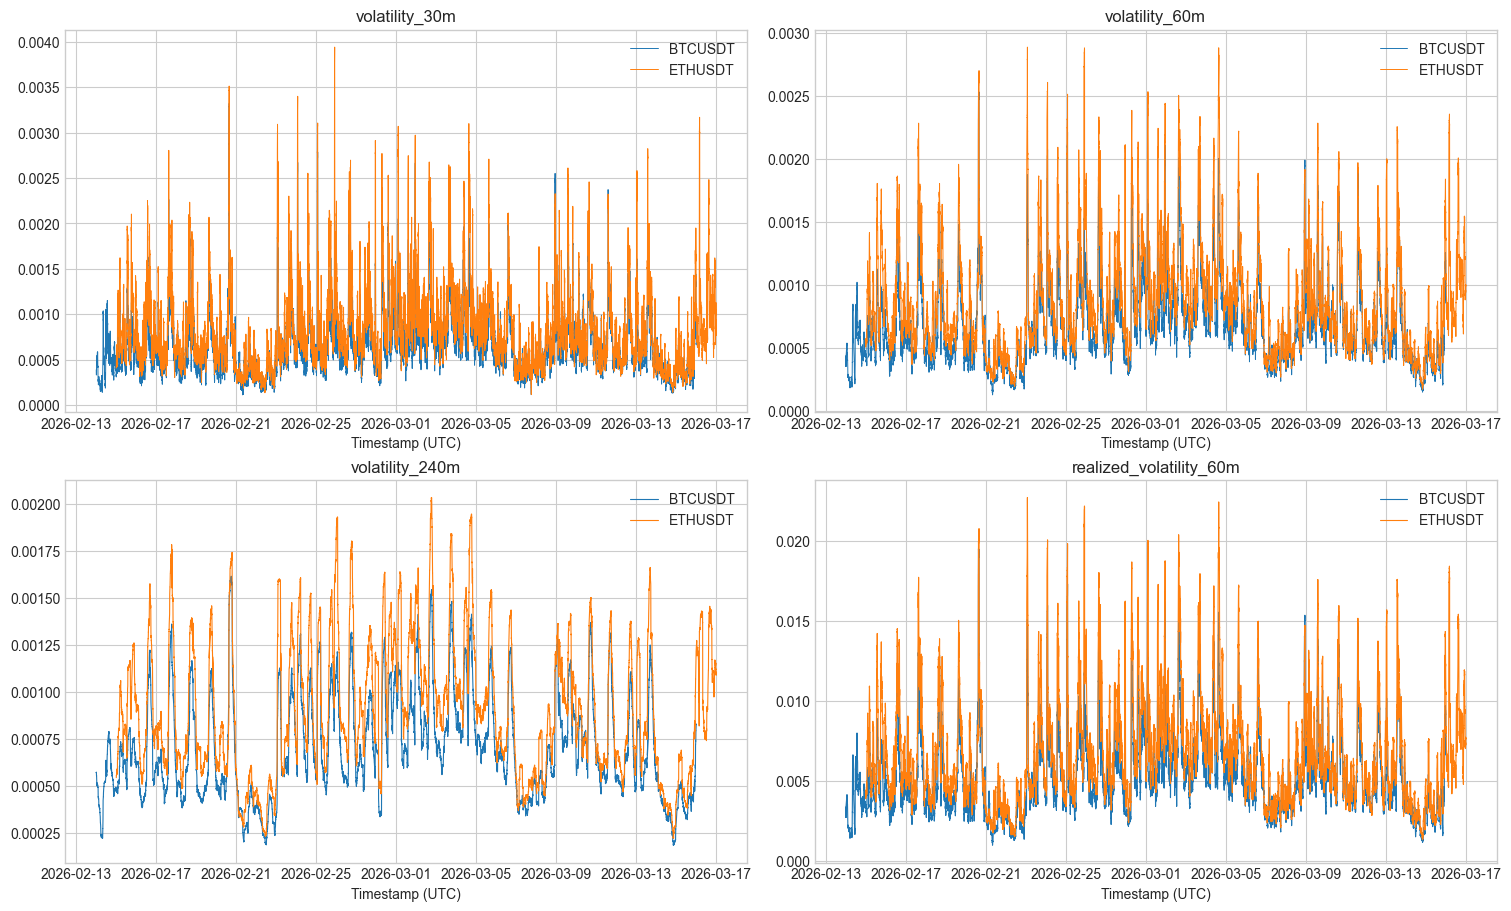

In [10]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 9), constrained_layout=True)
for symbol in ASSETS:
    recent_df = recent_frames[symbol]
    axes[0, 0].plot(recent_df["timestamp"], recent_df["volatility_30m"], label=symbol, linewidth=0.7)
    axes[0, 1].plot(recent_df["timestamp"], recent_df["volatility_60m"], label=symbol, linewidth=0.7)
    axes[1, 0].plot(recent_df["timestamp"], recent_df["volatility_240m"], label=symbol, linewidth=0.8)
    axes[1, 1].plot(recent_df["timestamp"], recent_df["realized_volatility_60m"], label=symbol, linewidth=0.8)

axes[0, 0].set_title("volatility_30m")
axes[0, 1].set_title("volatility_60m")
axes[1, 0].set_title("volatility_240m")
axes[1, 1].set_title("realized_volatility_60m")

for ax in axes.flat:
    ax.set_xlabel("Timestamp (UTC)")
    ax.legend()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())

plt.show()

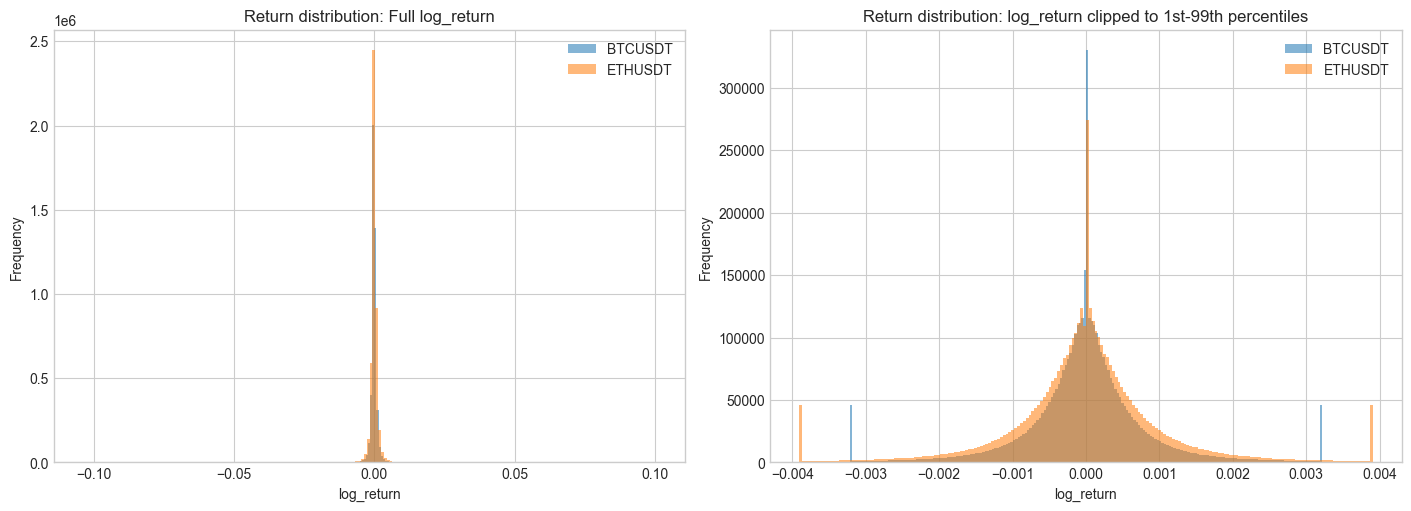

In [11]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), constrained_layout=True)
for symbol, color in zip(ASSETS, ["tab:blue", "tab:orange"]):
    returns = asset_bundles[symbol]["df"]["log_return"].dropna()
    axes[0].hist(returns, bins=200, alpha=0.55, label=symbol, color=color)
    clipped = returns.clip(lower=returns.quantile(0.01), upper=returns.quantile(0.99))
    axes[1].hist(clipped, bins=200, alpha=0.55, label=symbol, color=color)

axes[0].set_title("Return distribution: Full log_return")
axes[1].set_title("Return distribution: log_return clipped to 1st-99th percentiles")
for ax in axes:
    ax.set_xlabel("log_return")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.show()

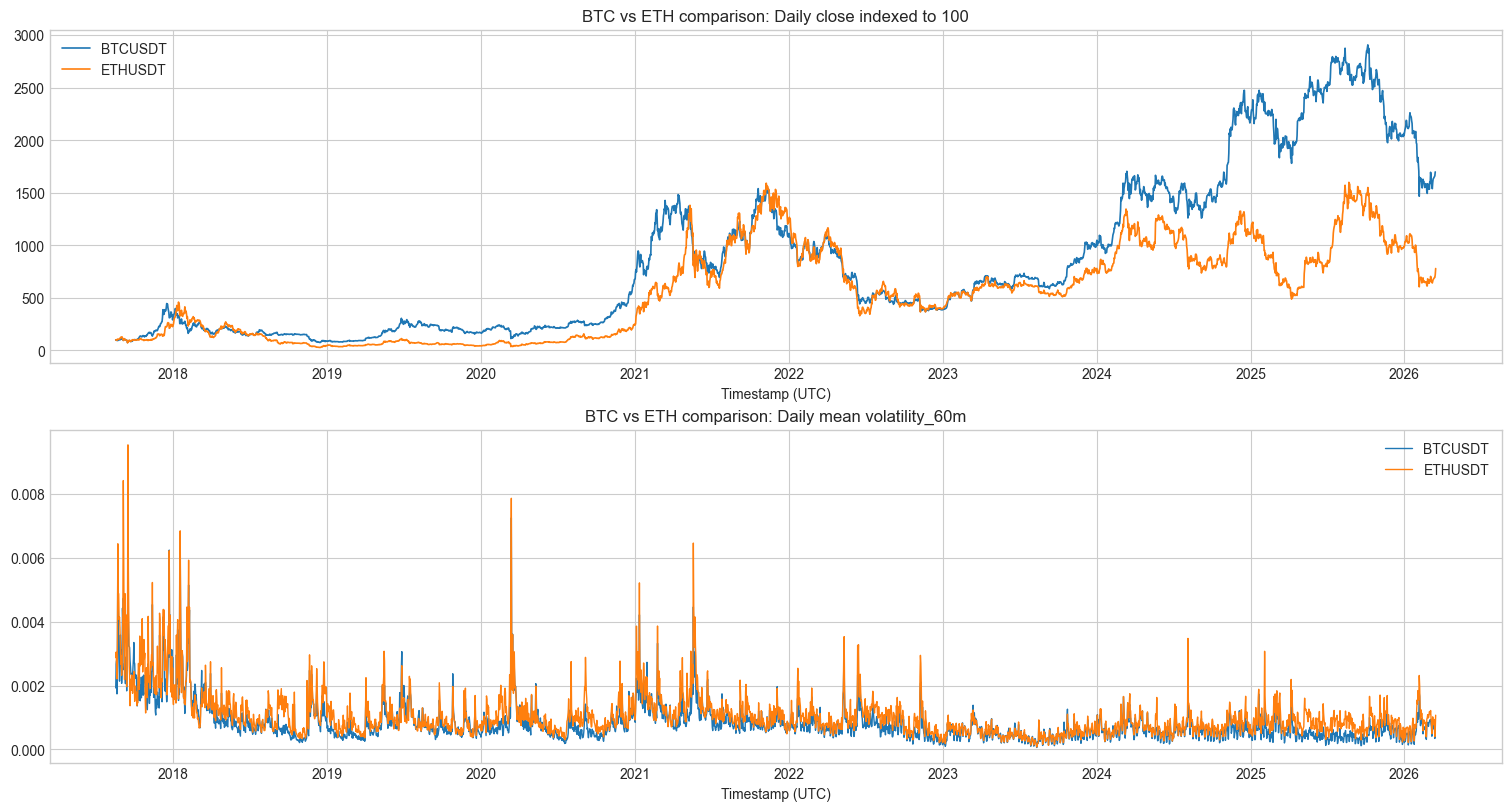

In [12]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 8), constrained_layout=True)
for symbol in ASSETS:
    indexed_close = 100 * daily_close[symbol] / daily_close[symbol].iloc[0]
    daily_feature = asset_bundles[symbol]["df"].set_index("timestamp")["volatility_60m"].resample("1D").mean()
    axes[0].plot(indexed_close.index, indexed_close.values, label=symbol, linewidth=1.2)
    axes[1].plot(daily_feature.index, daily_feature.values, label=symbol, linewidth=1.0)

axes[0].set_title("BTC vs ETH comparison: Daily close indexed to 100")
axes[1].set_title("BTC vs ETH comparison: Daily mean volatility_60m")
for ax in axes:
    ax.set_xlabel("Timestamp (UTC)")
    ax.legend()

plt.show()

# 10. Motif-readiness discussion

A matrix profile algorithm expects a contiguous numeric series. That makes missing timestamp handling a methodological decision rather than a purely technical one.

The main options are:

- Leave the data irregular and analyze only observed rows.
- Reindex to an explicit minute grid to make gaps visible.
- Forward-fill prices so plots and coarse aggregates look continuous.
- Restrict motif discovery to contiguous observed subsequences.

For this thesis, the conservative choice is:

- Reindex for diagnostics only.
- Allow price forward-fill only for visualization support.
- Do not create synthetic returns across real gaps.
- Use contiguous observed `log_return` blocks as the first motif-ready representation.

This avoids hiding real data outages and keeps the first matrix profile experiments interpretable.

# 11. Create motif-ready candidate series without overwriting source files

The next step is to create a candidate series for motif discovery from the largest contiguous observed `log_return` block for each asset. This leaves the original processed parquet untouched. Optional export is disabled by default.

In [13]:
diagnostic_frames = {}
motif_candidates = {}
motif_summary_rows = []

for symbol, bundle in asset_bundles.items():
    df = bundle["df"].copy()
    diagnostic_frames[symbol] = make_reindexed_diagnostic_frame(df)

    block_table = build_contiguous_block_table(df, value_column="log_return")
    best_block = block_table.iloc[0]
    candidate = df.loc[
        (df["timestamp"] >= best_block["start"]) & (df["timestamp"] <= best_block["end"]),
        ["timestamp", "log_return"],
    ].dropna().reset_index(drop=True)

    motif_candidates[symbol] = {
        "candidate": candidate,
        "block_table": block_table,
    }

    motif_summary_rows.append(
        {
            "symbol": symbol,
            "candidate_feature": "log_return",
            "candidate_rows": len(candidate),
            "candidate_start": candidate["timestamp"].min(),
            "candidate_end": candidate["timestamp"].max(),
            "largest_contiguous_block_rows": int(best_block["rows"]),
        }
    )

motif_candidate_summary = pd.DataFrame(motif_summary_rows).sort_values("symbol").reset_index(drop=True)
display(motif_candidate_summary)

for symbol in ASSETS:
    print(f"Largest contiguous log_return blocks for {symbol}")
    display(motif_candidates[symbol]["block_table"].head(10))

,symbol,candidate_feature,candidate_rows,candidate_start,candidate_end,largest_contiguous_block_rows
0,BTCUSDT,log_return,1565880,2023-03-24 14:00:00+00:00,2026-03-15 23:59:00+00:00,1565880
1,ETHUSDT,log_return,1567320,2023-03-24 14:00:00+00:00,2026-03-16 23:59:00+00:00,1567320


Largest contiguous log_return blocks for BTCUSDT


,block_id,start,end,rows
0,36,2023-03-24 14:00:00+00:00,2026-03-15 23:59:00+00:00,1565880
1,35,2021-09-29 09:00:00+00:00,2023-03-24 12:39:00+00:00,779260
2,26,2020-06-28 05:30:00+00:00,2020-11-30 05:59:00+00:00,223230
3,9,2018-02-11 04:35:00+00:00,2018-06-26 01:59:00+00:00,194245
4,14,2018-11-14 09:00:00+00:00,2019-03-12 01:59:00+00:00,169500
5,33,2021-04-25 08:45:00+00:00,2021-08-13 01:59:00+00:00,157995
6,12,2018-07-04 08:00:00+00:00,2018-10-19 05:59:00+00:00,153960
7,18,2019-08-15 10:00:00+00:00,2019-11-13 01:59:00+00:00,129120
8,2,2017-09-06 23:00:00+00:00,2017-12-04 06:00:00+00:00,127141
9,21,2019-11-25 04:00:00+00:00,2020-02-09 01:59:00+00:00,109320


Largest contiguous log_return blocks for ETHUSDT


,block_id,start,end,rows
0,36,2023-03-24 14:00:00+00:00,2026-03-16 23:59:00+00:00,1567320
1,35,2021-09-29 09:00:00+00:00,2023-03-24 12:39:00+00:00,779260
2,26,2020-06-28 05:30:00+00:00,2020-11-30 05:59:00+00:00,223230
3,9,2018-02-11 04:35:00+00:00,2018-06-26 01:59:00+00:00,194245
4,14,2018-11-14 09:00:00+00:00,2019-03-12 01:59:00+00:00,169500
5,33,2021-04-25 08:45:00+00:00,2021-08-13 01:59:00+00:00,157995
6,12,2018-07-04 08:00:00+00:00,2018-10-19 05:59:00+00:00,153960
7,18,2019-08-15 10:00:00+00:00,2019-11-13 01:59:00+00:00,129120
8,2,2017-09-06 23:00:00+00:00,2017-12-04 06:00:00+00:00,127141
9,21,2019-11-25 04:00:00+00:00,2020-02-09 01:59:00+00:00,109320


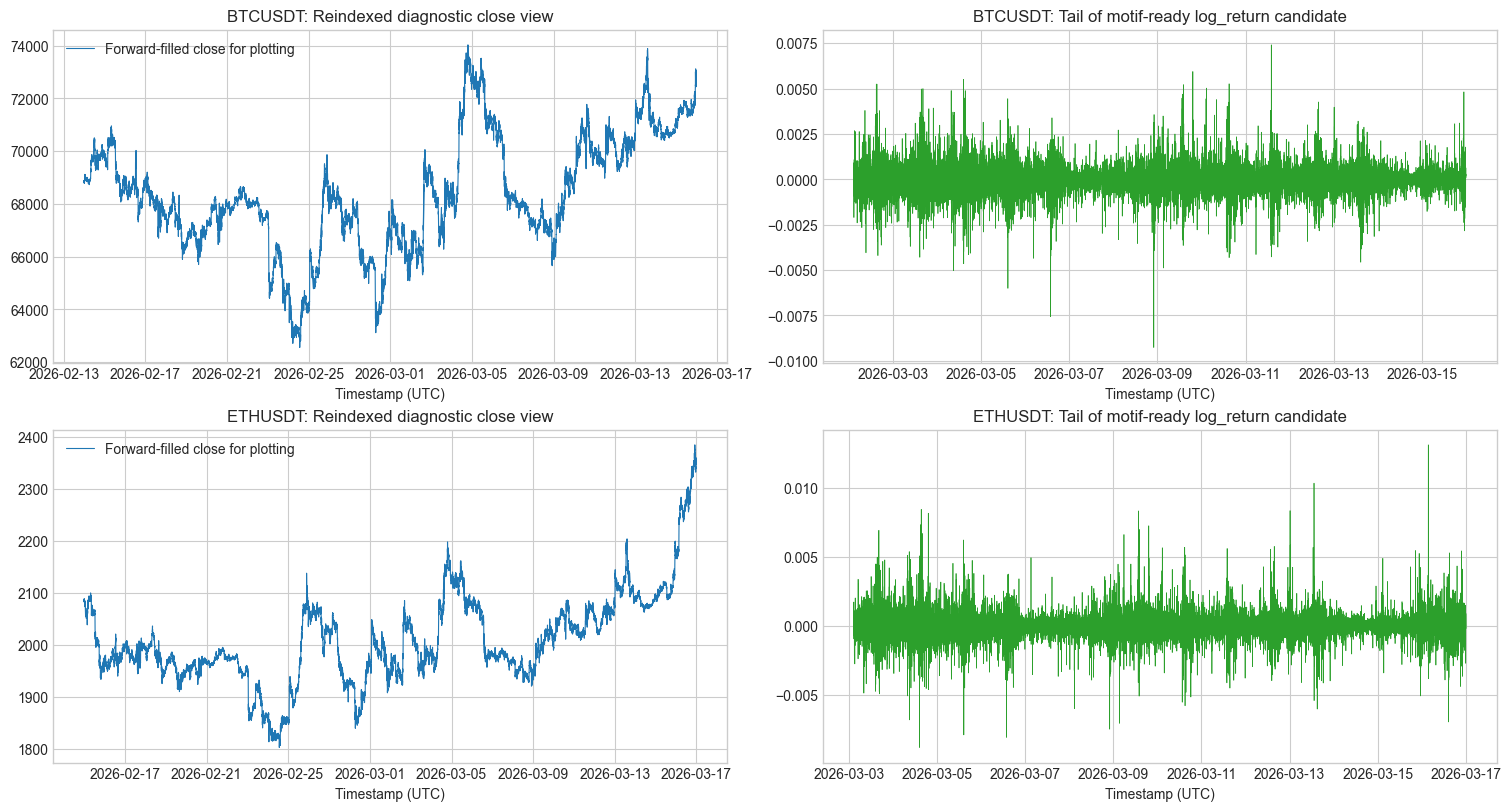

In [14]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 8), constrained_layout=True)
for row_idx, symbol in enumerate(ASSETS):
    diagnostic = diagnostic_frames[symbol]
    recent_diagnostic = diagnostic.loc[diagnostic["timestamp"] >= diagnostic["timestamp"].max() - pd.Timedelta(days=RECENT_WINDOW_DAYS)].copy()
    candidate_tail = motif_candidates[symbol]["candidate"].tail(20_000)

    axes[row_idx, 0].plot(recent_diagnostic["timestamp"], recent_diagnostic["close_ffill_for_plot"], linewidth=0.8, color="tab:blue", label="Forward-filled close for plotting")
    if recent_diagnostic["synthetic_gap"].any():
        gap_times = recent_diagnostic.loc[recent_diagnostic["synthetic_gap"], "timestamp"]
        axes[row_idx, 0].scatter(gap_times, [recent_diagnostic["close_ffill_for_plot"].median()] * len(gap_times), s=10, color="tab:red", alpha=0.5, label="Missing minute")
    axes[row_idx, 0].set_title(f"{symbol}: Reindexed diagnostic close view")
    handles, labels = axes[row_idx, 0].get_legend_handles_labels()
    if labels:
        axes[row_idx, 0].legend(loc="upper left")

    axes[row_idx, 1].plot(candidate_tail["timestamp"], candidate_tail["log_return"], linewidth=0.5, color="tab:green")
    axes[row_idx, 1].set_title(f"{symbol}: Tail of motif-ready log_return candidate")

for ax in axes.flat:
    ax.set_xlabel("Timestamp (UTC)")
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())

plt.show()

In [15]:
SAVE_MOTIF_READY_OUTPUTS = False

if SAVE_MOTIF_READY_OUTPUTS:
    output_dir = project_root / "data" / "interim" / "crypto" / "1min"
    output_dir.mkdir(parents=True, exist_ok=True)
    for symbol, payload in motif_candidates.items():
        output_path = output_dir / f"{symbol}_1m_motif_ready_log_return.parquet"
        payload["candidate"].to_parquet(output_path, index=False)
        print(f"Saved {symbol} motif-ready candidate to {output_path}")
else:
    print("Interim export disabled. Set SAVE_MOTIF_READY_OUTPUTS = True to persist the candidate files.")

Interim export disabled. Set SAVE_MOTIF_READY_OUTPUTS = True to persist the candidate files.


# 12. Final conclusions and next steps

This notebook establishes the first defensible preprocessing stance for motif discovery:

- BTC and ETH are schema-consistent and directly comparable.
- Leading NaNs in returns and rolling features are expected warm-up effects.
- Missing timestamps remain a real continuity issue and should be kept explicit.
- Reindexing is useful for diagnostics, not as a silent way to fabricate motif input data.
- Forward-filling price can support visualization, but synthetic returns should not be created across missing intervals.
- The recommended first motif-ready representation is the largest contiguous observed `log_return` block for each asset.

Next step after this notebook: run first-stage STUMPY matrix profile experiments on BTCUSDT using a manageable subset taken from the motif-ready `log_return` candidate series.